# Normative Modelling: A Hands-On Tutorial
### From first principles to PCNtoolkit (≈ 2 hours)

**Audience:** graduate students and researchers comfortable with basic Python and regression.

**By the end of this session you will be able to:**
1. Explain why normative modelling complements (and differs from) case–control analysis.
2. Build a normative model from scratch: non-linear mean, site effects, and age-varying variance.
3. Evaluate a normative model properly (explained variance, MSLL, calibration of z-scores).
4. Fit and evaluate warped Bayesian linear regression models with **PCNtoolkit 1.x**.
5. Map individual deviations in a clinical group and interpret heterogeneity.

| Time | Section |
|---|---|
| 0:00 – 0:10 | 0. Setup · 1. Why normative modelling? |
| 0:10 – 0:20 | 2. The dataset |
| 0:20 – 1:00 | 3. Building a normative model from scratch |
| 1:00 – 1:10 | ☕ Break |
| 1:10 – 1:35 | 4. Normative modelling with PCNtoolkit |
| 1:35 – 1:52 | 5. Clinical application: mapping individual deviations |
| 1:52 – 2:00 | 6. Pitfalls, discussion & wrap-up |

> **Data:** everything runs on a *simulated* multi-site cortical thickness dataset, so no downloads or data-use agreements are needed, and — unusually for real data — we know the ground truth.

## 0. Setup

The from-scratch sections need only `numpy`, `scipy`, `pandas`, `matplotlib` and `scikit-learn`.
Section 4 additionally needs the **latest PCNtoolkit (v1.x)**, which uses the new object-oriented API (`NormData`, `NormativeModel`, `BLR`, `HBR`):

```bash
pip install -U pcntoolkit
```

> Older tutorials and papers use the pre-1.0 `estimate(covfile, respfile, ...)` function. That API has been replaced; don't mix code from the two versions. A fresh virtual environment (Python ≥ 3.10) is the easiest route.

In [12]:
# ---------------------------------------------------------------------------
# Imports and global settings
# ---------------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")          # keep the notebook output readable during teaching

import numpy as np                         # arrays and linear algebra
import pandas as pd                        # tabular data (one row per subject)
import matplotlib.pyplot as plt            # plotting
from scipy import stats, optimize          # distributions/tests; numerical optimisation (Section 3.4)
from sklearn.preprocessing import SplineTransformer        # B-spline basis for non-linear age effects
from sklearn.model_selection import train_test_split       # held-out test set of controls

# A single seeded random generator makes every run of the notebook produce
# exactly the same simulated data, so everyone in the room sees the same numbers.
rng = np.random.default_rng(2026)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. Why normative modelling? (≈ 10 min)

**The case–control paradigm** asks: *does the average patient differ from the average control?*
It implicitly assumes patients are a homogeneous group. For most psychiatric and many neurological conditions this is false: two people with the same diagnosis can have very different underlying biology.

**Normative modelling** borrows the logic of paediatric growth charts:
1. Learn the *distribution* of a brain measure (not just its mean) across a large reference population, as a function of covariates like age, sex and scanner site.
2. Place each new individual on that chart and ask *how atypical are they?*, expressed as a **deviation (z) score**.

$$z_{i} = \frac{y_i - \hat{\mu}(x_i)}{\hat{\sigma}(x_i)}$$

Two things are essential and easy to get wrong:
- $\hat\mu(x)$ must capture **non-linear** trajectories (brain development and ageing are not straight lines).
- $\hat\sigma(x)$ must capture how **variability** changes with covariates — otherwise z-scores are miscalibrated, and "extreme" means different things at different ages.

> **Discussion prompt (2 min):** A treatment works for 20% of patients who share an abnormality in region X, while the other 80% have abnormalities elsewhere. What would a case–control study of region X show?

## 2. The dataset (≈ 10 min)

We simulate cortical thickness (mm) in **8 regions** for **3,000 healthy controls** from **4 scanner sites** with different age ranges, plus **240 patients**. The simulation deliberately includes the things that make real data hard:

- a **non-linear** lifespan trajectory (early thinning, then slower decline),
- **heteroscedasticity** — variance grows with age,
- **site effects** on both location and scale,
- **skewed** noise in some regions,
- **heterogeneous** patients: each has abnormal thinning in a *different* 1–3 regions (and some have none).

You don't need to study the simulation code in detail; skim it and move on.

In [13]:
# ===========================================================================
# 1. Study design: regions, sites and how many subjects each site contributes
# ===========================================================================
ROIS = ["frontal_pole", "precentral", "sup_temporal", "insula",
        "precuneus", "lat_occipital", "entorhinal", "cingulate"]
SITES = ["site_A", "site_B", "site_C", "site_D"]

# Each site recruits a different age range -> site and age are CONFOUNDED,
# which is realistic (e.g. a paediatric cohort vs. an ageing cohort).
SITE_AGE = {"site_A": (6, 25), "site_B": (18, 60), "site_C": (40, 88), "site_D": (6, 88)}
SITE_N = {"site_A": 700, "site_B": 800, "site_C": 700, "site_D": 800}
N_ROI = len(ROIS)

# ===========================================================================
# 2. Ground-truth parameters (the "true" normative model we try to recover)
# ===========================================================================
# One row per region. Rows = regions, columns = parameters of the true curve.
P = pd.DataFrame({
    "base":    rng.uniform(2.4, 3.0, N_ROI),    # thickness level (mm) in young adulthood
    "growth":  rng.uniform(0.15, 0.35, N_ROI),  # extra thickness in childhood that is lost quickly
    "decline": rng.uniform(0.35, 0.65, N_ROI),  # total thinning across the adult lifespan
    "sd0":     rng.uniform(0.08, 0.12, N_ROI),  # between-subject SD at age 6
    "skew_a":  [0, 1, 2, 3, 0, 4, 8, 6],        # noise skewness: 0 = symmetric, larger = long upper tail
}, index=ROIS)

# Scanner/site effects: each site shifts the mean (offset) and stretches the
# spread (scale) of every region differently. Shape: (n_sites, n_regions).
site_offset = rng.normal(0, 0.06, (len(SITES), N_ROI))
site_scale = rng.uniform(0.85, 1.25, (len(SITES), N_ROI))

def true_mu(age, p):
    # True mean trajectory: fast childhood thinning (exponential term)
    # plus accelerating adult decline (power term). Deliberately NON-linear.
    return p.base + p.growth * np.exp(-(age - 6) / 5) - p.decline * ((age - 6) / 80) ** 1.5

def true_sd(age, p):
    # True SD grows linearly with age (up to +80% by age 86) -> HETEROSCEDASTIC data.
    return p.sd0 * (1 + 0.8 * (age - 6) / 80)

def std_skewnorm(a, size):
    # Draw skew-normal noise and rescale it to mean 0, SD 1, so that the
    # skewness parameter `a` changes only the SHAPE of the distribution,
    # not its location or spread.
    delta = a / np.sqrt(1 + a ** 2)
    m = delta * np.sqrt(2 / np.pi)                  # theoretical mean of a skew-normal
    return (stats.skewnorm.rvs(a, size=size, random_state=rng) - m) / np.sqrt(1 - m ** 2)

def simulate(age, sex, site_idx):
    # Returns an (n_subjects x n_regions) matrix of cortical thickness values:
    #   y = true mean(age) + sex effect + site offset  +  true SD(age) * site scale * noise
    Y = np.zeros((len(age), N_ROI))
    for j, roi in enumerate(ROIS):
        p = P.loc[roi]
        mu = true_mu(age, p) + 0.03 * sex + site_offset[site_idx, j]
        sd = true_sd(age, p) * site_scale[site_idx, j]
        Y[:, j] = mu + sd * std_skewnorm(p.skew_a, len(age))
    return Y

# ===========================================================================
# 3. Healthy controls (the reference cohort for the normative model)
# ===========================================================================
rows = []
for s_idx, s in enumerate(SITES):
    n = SITE_N[s]
    age = rng.uniform(*SITE_AGE[s], n)              # ages uniformly spread within the site's range
    sex = rng.integers(0, 2, n)                     # 0/1 coding
    rows.append(pd.DataFrame({"age": age, "sex": sex, "site": s, "site_idx": s_idx}))
controls = pd.concat(rows, ignore_index=True)
controls[ROIS] = simulate(controls.age.values, controls.sex.values, controls.site_idx.values)
controls["dx"] = "control"

# ===========================================================================
# 4. Patients: same generative model PLUS heterogeneous regional thinning
# ===========================================================================
n_pat = 240
pat_site = rng.choice([1, 2, 3], n_pat)            # patients come from the adult sites (B, C, D)
pat_age = np.array([rng.uniform(max(18, SITE_AGE[SITES[i]][0]), SITE_AGE[SITES[i]][1]) for i in pat_site])
patients = pd.DataFrame({"age": pat_age, "sex": rng.integers(0, 2, n_pat),
                         "site": [SITES[i] for i in pat_site], "site_idx": pat_site})
patients[ROIS] = simulate(patients.age.values, patients.sex.values, patients.site_idx.values)

# `truth[i, j]` records whether patient i really has an abnormality in region j.
# We'll use it in Section 5 to check how well deviation scores recover the truth
# (a luxury we never have with real data).
truth = np.zeros((n_pat, N_ROI), dtype=bool)
roi_prob = np.array([1, 1, 1, 2, 1, 1, 2.5, 1])   # insula & entorhinal are affected more often
roi_prob /= roi_prob.sum()
for i in range(n_pat):
    if rng.random() < 0.35:                         # 35% of patients have NO abnormality at all
        continue
    k = rng.choice([1, 2, 3], p=[0.6, 0.3, 0.1])    # the rest have 1-3 affected regions...
    for j in rng.choice(N_ROI, k, replace=False, p=roi_prob):   # ...and WHICH regions varies per patient
        # Thin the region by 3-4.5 SDs of the healthy variation for that person's age and site
        sd = true_sd(patients.age[i], P.iloc[j]) * site_scale[patients.site_idx[i], j]
        patients.iloc[i, patients.columns.get_loc(ROIS[j])] -= rng.uniform(3, 4.5) * sd
        truth[i, j] = True
patients["dx"] = "patient"

# ===========================================================================
# 5. Split controls into training (fit the model) and test (evaluate it)
# ===========================================================================
# Stratifying by site guarantees every site is represented in both sets.
# Evaluating on held-out controls is essential: training-set z-scores look
# better calibrated than they really are.
train, test = train_test_split(controls, test_size=0.3, stratify=controls.site, random_state=0)
train, test = train.reset_index(drop=True), test.reset_index(drop=True)
print(f"train controls: {len(train)} | test controls: {len(test)} | patients: {len(patients)}")
train.head()

train controls: 2100 | test controls: 900 | patients: 240


,age,sex,site,site_idx,frontal_pole,precentral,sup_temporal,insula,precuneus,lat_occipital,entorhinal,cingulate,dx
0,52.942094,0,site_C,2,2.420433,2.468913,2.436699,2.334143,2.632684,2.563045,2.753815,2.432069,control
1,37.224883,1,site_D,3,2.597629,2.798072,2.605199,2.623856,2.396490,2.651953,2.737053,2.399619,control
2,18.132371,0,site_A,0,2.520110,2.845632,2.706835,2.508885,2.518574,2.778679,2.965896,2.787666,control
3,37.517272,0,site_D,3,2.482534,2.727022,2.434777,2.429746,2.437016,2.921519,2.613635,2.399068,control
4,7.428694,1,site_A,0,2.648717,2.950035,3.130860,2.837828,2.955128,3.471746,3.105060,2.602174,control


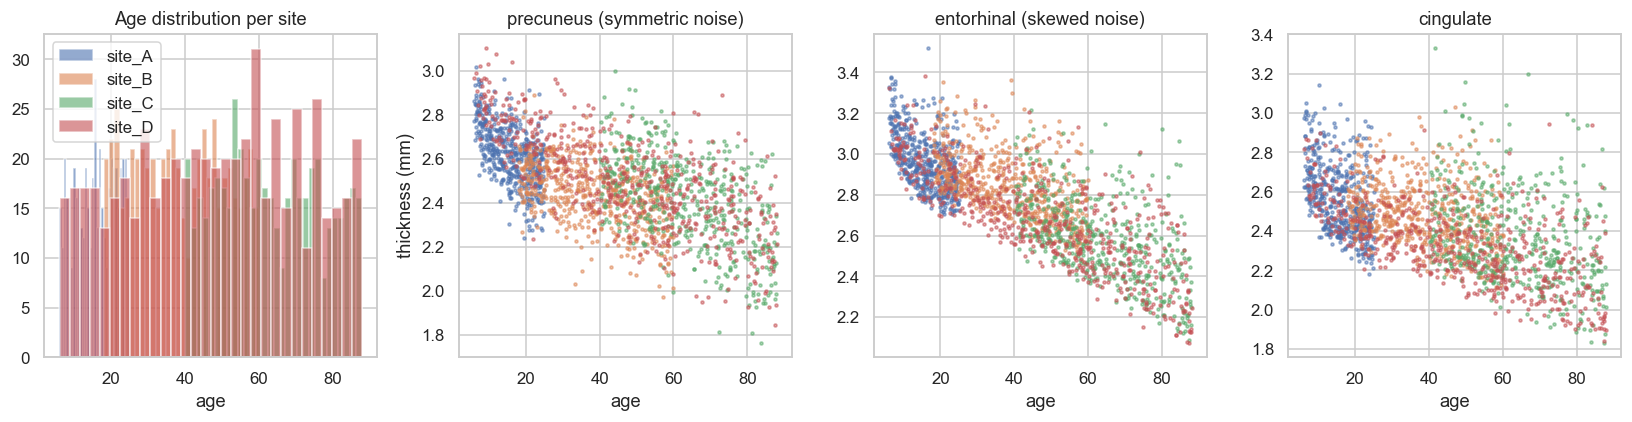

In [45]:
# Three panels: (1) age coverage of each site, (2) a region with symmetric
# noise, (3) a region with strongly skewed noise. Colours = sites.
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for s in SITES:
    d = train[train.site == s]
    axes[0].hist(d.age, bins=30, alpha=0.6, label=s)
    axes[1].scatter(d.age, d["precuneus"], s=4, alpha=0.5, label=s)
    axes[2].scatter(d.age, d["entorhinal"], s=4, alpha=0.5, label=s)
    axes[3].scatter(d.age, d["cingulate"], s=4, alpha=0.5, label=s)
axes[0].set(title="Age distribution per site", xlabel="age")
axes[1].set(title="precuneus (symmetric noise)", xlabel="age", ylabel="thickness (mm)")
axes[2].set(title="entorhinal (skewed noise)", xlabel="age")
axes[3].set(title="cingulate", xlabel="age")
axes[0].legend(); plt.tight_layout(); plt.show()

**Things to notice:**
- Sites cover different age ranges, so **site and age are confounded**. A model that ignores site will partly misattribute site differences to age.
- The spread of the data increases with age.
- The entorhinal cloud has a long upper tail — a Gaussian model will struggle there.

### A quick case–control analysis (the "traditional" view)
Let's compare patients with age-matched controls, region by region.

In [ ]:
# Classic case-control comparison, one region at a time.
# We restrict controls to adults because all patients are >= 18 years old.
adult_ctrl = test[test.age >= 18]
res = []
for roi in ROIS:
    t, p = stats.ttest_ind(patients[roi], adult_ctrl[roi])          # two-sample t-test
    # Cohen's d: mean difference in units of the control SD (negative = patients thinner)
    d = (patients[roi].mean() - adult_ctrl[roi].mean()) / adult_ctrl[roi].std()
    res.append({"roi": roi, "cohen_d": round(d, 2), "p": p,
                # ground truth: what fraction of patients is actually affected in this region?
                "% patients truly abnormal here": round(100 * truth[:, ROIS.index(roi)].mean(), 1)})
pd.DataFrame(res).set_index("roi")

,cohen_d,p,% patients truly abnormal here
roi,,,
frontal_pole,-0.44,2.048296e-07,8.3
precentral,-0.49,1.060911e-09,7.9
sup_temporal,-0.64,5.273801e-14,11.2
insula,-0.78,2.222979e-18,20.8
precuneus,-0.49,5.312625e-09,8.8
lat_occipital,-0.55,2.753921e-11,10.8
entorhinal,-0.69,3.121413e-16,21.2
cingulate,-0.39,2.443358e-06,9.2


Effect sizes are modest, yet we *know* that in every region a subset of patients is thinner by 3–4.5 SD. The group statistic cannot distinguish "every patient is a little thinner" from "a few patients are much thinner", and those two scenarios have very different clinical implications. Also note this crude comparison ignores age, sex and site differences between groups. Keep this table in mind; we'll revisit it in Section 5.

## 3. Building a normative model from scratch (≈ 40 min)

We'll build up the model in stages, evaluating each one. We focus on **one skewed region (`entorhinal`)** and **one symmetric region (`precuneus`)**, then scale up to all regions.

### 3.1 How do we know if a normative model is good?

A normative model makes a *probabilistic* prediction, so accuracy of the mean is not enough. We'll report:

| Metric | What it measures | Good value |
|---|---|---|
| **EV** (explained variance) | how well the mean fits | higher |
| **MSLL** (mean standardised log loss) | quality of the full predictive distribution, relative to a trivial model that predicts the training mean & variance | more negative |
| **z mean / z sd** | calibration of location / scale | 0 / 1 |
| **skew, excess kurtosis of z** | shape calibration (tails!) | 0 / 0 |
| **% \|z\| > 1.96** | tail calibration | ≈ 5% |

The last three matter most for clinical use: if the model's tails are wrong, "extreme deviations" are wrong.

In [ ]:
def evaluate(y, mu, sd, y_train):
    # Evaluate a probabilistic prediction N(mu, sd^2) against observed values y.
    #   y       : observed test values
    #   mu, sd  : the model's predicted mean and SD for each test subject
    #   y_train : training values, used to build the "trivial" baseline for MSLL
    z = (y - mu) / sd                                                # deviation scores

    # Log-likelihood of each observation under the model and under a trivial
    # model that ignores all covariates (just the training mean and SD).
    ll_model = stats.norm.logpdf(y, mu, sd)
    ll_trivial = stats.norm.logpdf(y, y_train.mean(), y_train.std())

    return {
        "EV": 1 - np.var(y - mu) / np.var(y),        # explained variance of the MEAN prediction
        "MSLL": np.mean(ll_trivial - ll_model),      # < 0 means better than trivial; more negative = better
        "z_mean": z.mean(), "z_sd": z.std(),         # should be ~0 and ~1
        "z_skew": stats.skew(z),                     # should be ~0 (symmetric)
        "z_exkurt": stats.kurtosis(z),               # excess kurtosis, should be ~0 (Gaussian tails)
        "% |z|>1.96": 100 * np.mean(np.abs(z) > 1.96),   # should be ~5%
    }

def calibration_by_age(z, age, bins=(6, 20, 40, 60, 88)):
    # Percentage of |z| > 1.96 within each age bin. A well-calibrated model gives
    # ~5% in EVERY bin, not just on average across the whole sample.
    cut = pd.cut(age, bins)
    return (pd.Series(np.abs(z) > 1.96).groupby(cut, observed=True).mean() * 100).round(1)

### 3.2 Stage 1 — the naive model: linear in age, constant variance

In [ ]:
roi = "precuneus"

# Design matrix = [intercept, age]  -> a straight line in age.
X_tr = np.column_stack([np.ones(len(train)), train.age])
X_te = np.column_stack([np.ones(len(test)), test.age])
y_tr, y_te = train[roi].values, test[roi].values

# Ordinary least squares for the mean...
beta, *_ = np.linalg.lstsq(X_tr, y_tr, rcond=None)
# ...and ONE residual SD for everybody (homoscedastic assumption).
sd_naive = np.std(y_tr - X_tr @ beta)

# Predict on held-out controls and compute their deviation scores.
mu_te = X_te @ beta
z_naive = (y_te - mu_te) / sd_naive

print(pd.Series(evaluate(y_te, mu_te, sd_naive, y_tr)).round(3))
print("\n% |z|>1.96 by age bin (target ≈ 5):\n", calibration_by_age(z_naive, test.age))

EV            0.393
MSLL         -0.250
z_mean        0.003
z_sd          0.976
z_skew        0.189
z_exkurt      0.296
% |z|>1.96    5.333
dtype: float64

% |z|>1.96 by age bin (target ≈ 5):
 age
(6, 20]      3.5
(20, 40]     2.5
(40, 60]     5.0
(60, 88]    11.0
dtype: float64


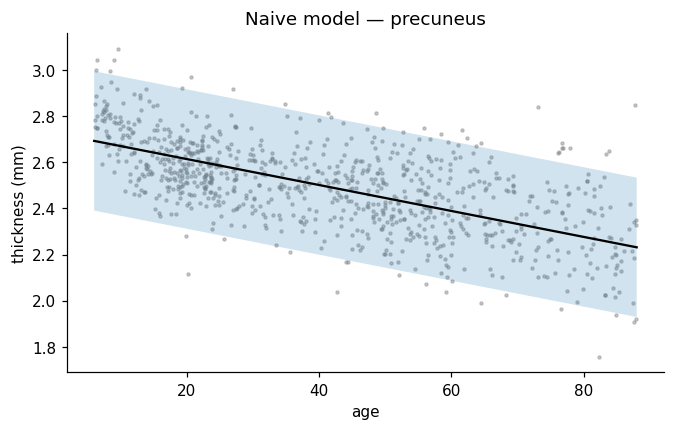

In [ ]:
grid = np.linspace(6, 88, 200)                 # a fine age grid for drawing curves (reused later)
line = beta[0] + beta[1] * grid                # fitted straight line

plt.figure(figsize=(7, 4))
plt.scatter(test.age, y_te, s=4, alpha=0.4, c="grey")
plt.plot(grid, line, "k")
# Shaded band = the model's 95% "normal range": mean ± 1.96 * (constant) SD
plt.fill_between(grid, line - 1.96 * sd_naive, line + 1.96 * sd_naive, alpha=0.2)
plt.title(f"Naive model — {roi}"); plt.xlabel("age"); plt.ylabel("thickness (mm)"); plt.show()

The straight line misses childhood thinning, and the constant band is too wide for the young and too narrow for the old. A 70-year-old flagged as "extreme" by this model may be perfectly typical for their age.

### 3.3 Stage 2 — non-linear mean (B-splines) + covariates

We expand age into a **cubic B-spline basis**: a set of smooth, local "bump" functions whose weighted sum can trace any smooth curve. This keeps the model linear in its parameters (so it's still just regression), while allowing non-linear trajectories. We also add **sex** and **site** (one-hot, first site as reference).

design matrix shape: (2100, 12)


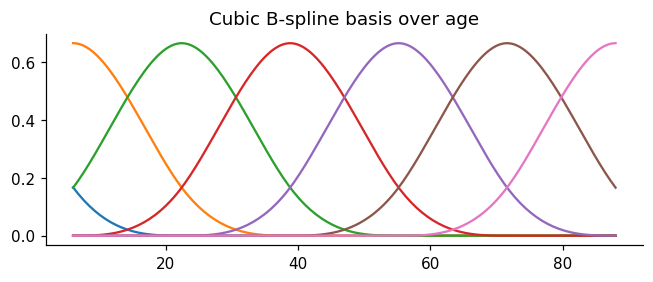

In [ ]:
class Design:
    # Builds a design matrix with the columns:
    #   [ intercept | B-spline basis of age | sex | site dummies (site_A = reference) ]
    #
    # Usage:  design = Design(n_knots=6).fit(train_df)   # learn knot positions from TRAINING ages
    #         X = design(any_df)                          # build the matrix for any data frame

    def __init__(self, n_knots=6):
        # More knots = a more flexible curve (but a higher risk of overfitting).
        self.n_knots = n_knots

    def fit(self, df):
        # Knots are placed at quantiles of the training ages. We fit them ONCE on
        # the training data and reuse them for test/patients, so every data set is
        # expressed in exactly the same basis.
        #   degree=3            -> cubic splines (smooth curves)
        #   include_bias=False  -> drop one basis function; our explicit intercept replaces it
        #   extrapolation       -> continue linearly beyond the training age range
        self.spl = SplineTransformer(n_knots=self.n_knots, degree=3, include_bias=False,
                                     extrapolation="linear").fit(df[["age"]])
        return self

    def __call__(self, df, sex=True, site=True):
        cols = [np.ones((len(df), 1)),                    # intercept
                self.spl.transform(df[["age"]])]          # one column per spline basis function
        if sex:
            cols.append(df[["sex"]].values)               # sex (0/1)
        if site:
            # One 0/1 column per site except the first (reference) site, to avoid
            # perfect collinearity with the intercept.
            cols.append(np.column_stack([(df.site == s).values for s in SITES[1:]]).astype(float))
        return np.hstack(cols)

design = Design(n_knots=6).fit(train)
Xm_tr, Xm_te = design(train), design(test)
print("design matrix shape:", Xm_tr.shape)    # (subjects, 1 + splines + 1 + 3)

# Visualise the basis functions: the model's mean curve will be a weighted sum of these bumps.
B = design.spl.transform(pd.DataFrame({"age": grid}))
plt.figure(figsize=(7, 2.5)); plt.plot(grid, B); plt.title("Cubic B-spline basis over age"); plt.show()

In [ ]:
# Same least-squares recipe as Stage 1, just with the richer design matrix.
beta, *_ = np.linalg.lstsq(Xm_tr, y_tr, rcond=None)
sd_homo = np.std(y_tr - Xm_tr @ beta)          # still ONE SD for everybody
mu_te = Xm_te @ beta
z_spline = (y_te - mu_te) / sd_homo

print(pd.Series(evaluate(y_te, mu_te, sd_homo, y_tr)).round(3))
print("\n% |z|>1.96 by age bin:\n", calibration_by_age(z_spline, test.age))

EV            0.501
MSLL         -0.348
z_mean        0.009
z_sd          0.970
z_skew        0.157
z_exkurt      0.927
% |z|>1.96    4.444
dtype: float64

% |z|>1.96 by age bin:
 age
(6, 20]      0.5
(20, 40]     1.6
(40, 60]     4.3
(60, 88]    12.0
dtype: float64


The mean fit (EV) improves substantially, but calibration across age is still poor: the variance problem remains. Overall "% |z|>1.96" can look fine while being badly wrong within subgroups — **always check calibration conditionally**, by age, site and sex.

### 3.4 Stage 3 — heteroscedastic model: modelling the variance

We now let *both* the mean and the log standard deviation depend on covariates:

$$y \sim \mathcal{N}\big(\mu(x),\ \sigma(x)^2\big),\qquad \mu(x) = X_\mu\beta,\qquad \log\sigma(x) = X_\sigma\gamma$$

and estimate $\beta, \gamma$ jointly by maximum likelihood. The negative log-likelihood and its gradients are simple enough to write by hand:

$$\text{NLL} = \sum_i \Big[\log\sigma_i + \tfrac{1}{2}\,r_i^2/\sigma_i^2\Big],\quad r_i = y_i - \mu_i$$

In [ ]:
class GaussianNormativeModel:
    # Heteroscedastic Gaussian normative model:
    #     y ~ Normal( mu = Xm @ beta,  sigma = exp(Xv @ gamma) )
    # Xm: design for the MEAN (age splines + sex + site)
    # Xv: design for the log-SD (fewer age splines + optionally site). Modelling log(sigma)
    #     rather than sigma guarantees the predicted SD is always positive.

    def __init__(self, n_knots_mean=6, n_knots_var=4, var_site=True, ridge=1e-2):
        self.dm = Design(n_knots_mean)           # design builder for the mean
        self.dv = Design(n_knots_var)            # design builder for the variance (smoother: fewer knots)
        self.var_site = var_site                 # allow each site its own noise level?
        self.ridge = ridge                       # small penalty that keeps variance weights stable

    def _X(self, df):
        # Build both design matrices for a data frame (sex is left out of the variance model).
        return self.dm(df), self.dv(df, sex=False, site=self.var_site)

    def fit(self, df, y):
        self.dm.fit(df); self.dv.fit(df)
        Xm, Xv = self._X(df)
        pm = Xm.shape[1]                         # number of mean parameters (to split theta later)

        # Sensible starting values: OLS for the mean, a constant log-SD for the variance.
        b0, *_ = np.linalg.lstsq(Xm, y, rcond=None)
        g0 = np.zeros(Xv.shape[1]); g0[0] = np.log(np.std(y - Xm @ b0))

        def nll(theta):
            # Negative log-likelihood (dropping constants) and its gradient.
            # theta = [beta (mean weights), gamma (log-SD weights)]
            b, g = theta[:pm], theta[pm:]
            r = y - Xm @ b                       # residuals
            logs = Xv @ g                        # log sigma for every subject
            s2 = np.exp(2 * logs)                # sigma^2
            val = np.sum(logs + 0.5 * r ** 2 / s2) + 0.5 * self.ridge * np.sum(g[1:] ** 2)
            # Analytic gradients make the optimiser fast and precise:
            grad_b = -Xm.T @ (r / s2)                    # d NLL / d beta
            grad_g = Xv.T @ (1 - r ** 2 / s2)            # d NLL / d gamma
            grad_g[1:] += self.ridge * g[1:]             # gradient of the ridge penalty (intercept unpenalised)
            return val, np.concatenate([grad_b, grad_g])

        # jac=True tells scipy that nll returns (value, gradient).
        res = optimize.minimize(nll, np.concatenate([b0, g0]), jac=True, method="L-BFGS-B")
        self.beta, self.gamma = res.x[:pm], res.x[pm:]
        return self

    def predict(self, df):
        # Predicted mean and SD for each row of df.
        Xm, Xv = self._X(df)
        return Xm @ self.beta, np.exp(Xv @ self.gamma)

    def zscore(self, df, y):
        # Deviation score: how many (subject-specific) SDs above/below the expected value.
        mu, sd = self.predict(df)
        return (y - mu) / sd

nm = GaussianNormativeModel().fit(train, y_tr)
mu_te, sd_te = nm.predict(test)
z_hetero = (y_te - mu_te) / sd_te
print(pd.Series(evaluate(y_te, mu_te, sd_te, y_tr)).round(3))
print("\n% |z|>1.96 by age bin:\n", calibration_by_age(z_hetero, test.age))

EV            0.501
MSLL         -0.386
z_mean        0.001
z_sd          0.972
z_skew        0.025
z_exkurt      0.363
% |z|>1.96    4.333
dtype: float64

% |z|>1.96 by age bin:
 age
(6, 20]     6.6
(20, 40]    3.3
(40, 60]    3.1
(60, 88]    5.0
dtype: float64


In [ ]:
def compare_models(roi):
    # Fit the three stages for one region and return their test-set metrics side by side.
    y_tr, y_te = train[roi].values, test[roi].values
    out = {}

    # Stage 1: straight line in age, constant SD
    X1 = np.column_stack([np.ones(len(train)), train.age])
    X1t = np.column_stack([np.ones(len(test)), test.age])
    b, *_ = np.linalg.lstsq(X1, y_tr, rcond=None)
    out["1 naive"] = evaluate(y_te, X1t @ b, np.std(y_tr - X1 @ b), y_tr)

    # Stage 2: splines + sex + site for the mean, constant SD
    d = Design().fit(train)
    b, *_ = np.linalg.lstsq(d(train), y_tr, rcond=None)
    out["2 spline"] = evaluate(y_te, d(test) @ b, np.std(y_tr - d(train) @ b), y_tr)

    # Stage 3: splines for the mean AND for the log-SD
    m = GaussianNormativeModel().fit(train, y_tr)
    out["3 hetero"] = evaluate(y_te, *m.predict(test), y_tr)   # *m.predict unpacks (mu, sd)

    return pd.DataFrame(out).T.round(3)

for roi in ["precuneus", "entorhinal"]:          # a symmetric region vs. a skewed region
    print(f"\n=== {roi} ==="); print(compare_models(roi))


=== precuneus ===
             EV   MSLL  z_mean   z_sd  z_skew  z_exkurt  % |z|>1.96
1 naive   0.393 -0.250   0.003  0.976   0.189     0.296       5.333
2 spline  0.501 -0.348   0.009  0.970   0.157     0.927       4.444
3 hetero  0.501 -0.386   0.001  0.972   0.025     0.363       4.333

=== entorhinal ===
             EV   MSLL  z_mean   z_sd  z_skew  z_exkurt  % |z|>1.96
1 naive   0.606 -0.463  -0.065  1.028   0.873     0.963       5.111
2 spline  0.636 -0.502  -0.062  1.043   1.057     1.582       5.333
3 hetero  0.635 -0.527  -0.057  1.045   1.106     1.373       5.222


For `precuneus` the heteroscedastic Gaussian model is well calibrated. For `entorhinal`, however, the z-scores remain **skewed with heavy tails** — no amount of mean/variance modelling fixes a *shape* problem. Let's look.

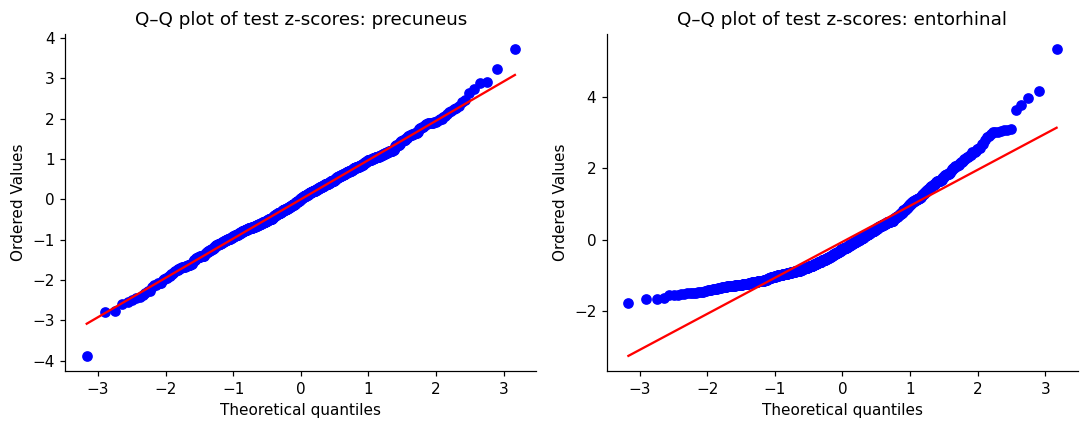

In [ ]:
# Q-Q plot: sorted test z-scores against the quantiles of a standard normal.
# Points on the diagonal = well-calibrated; bending in the tails = wrong shape.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, roi in zip(axes, ["precuneus", "entorhinal"]):
    m = GaussianNormativeModel().fit(train, train[roi].values)
    z = m.zscore(test, test[roi].values)
    stats.probplot(z, dist="norm", plot=ax)
    ax.set_title(f"Q–Q plot of test z-scores: {roi}")
plt.tight_layout(); plt.show()

The entorhinal Q–Q plot bends away from the line in the tails. Consequence: in the upper tail we'll produce *too many* "extreme" positive deviations, and in the lower tail the z-scores are compressed. Since clinical interest is usually in the tails, this matters. Section 4 fixes this with **likelihood warping** (a sinh-arcsinh transformation), which lets the model learn skew and kurtosis.

### 3.5 Centile curves ("brain charts")

The fitted model gives us the full predictive distribution at any age, so we can draw growth-chart-style centiles for any site and sex.

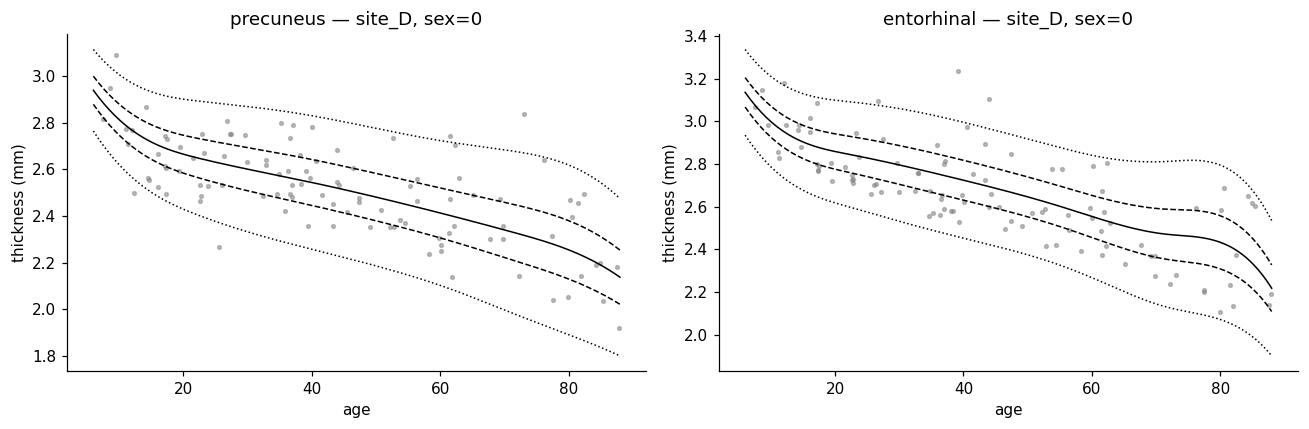

In [ ]:
def plot_centiles(model, roi, site="site_D", sex=0, ax=None, title=None):
    # Draw "brain chart" centile curves for one site/sex combination.
    ax = ax or plt.gca()

    # Build a synthetic data frame: every age on the grid, with a fixed site and sex.
    g = pd.DataFrame({"age": grid, "sex": sex, "site": site})
    mu, sd = model.predict(g)

    # Overlay real test subjects from the same site and sex.
    d = test[(test.site == site) & (test.sex == sex)]
    ax.scatter(d.age, d[roi], s=6, alpha=0.5, c="grey")

    # Under a Gaussian model the q-th centile is  mu + sd * Phi^-1(q).
    for q, ls in zip([0.025, 0.25, 0.5, 0.75, 0.975], [":", "--", "-", "--", ":"]):
        ax.plot(grid, mu + sd * stats.norm.ppf(q), "k", ls=ls, lw=1)
    ax.set(title=title or f"{roi} — {site}, sex={sex}", xlabel="age", ylabel="thickness (mm)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, roi in zip(axes, ["precuneus", "entorhinal"]):
    plot_centiles(GaussianNormativeModel().fit(train, train[roi].values), roi, ax=ax)
plt.tight_layout(); plt.show()

### 3.6 Scaling up: one model per region

In practice we fit an independent model for every brain measure (region, vertex, or voxel). We'll keep the z-scores for test controls and patients for Section 5.

In [ ]:
# Fit one independent normative model per region (the standard "mass-univariate" approach).
models = {}                                # fitted model per region
Z_test = np.zeros((len(test), N_ROI))      # z-scores of held-out controls  (subjects x regions)
Z_pat = np.zeros((n_pat, N_ROI))           # z-scores of patients           (subjects x regions)
metrics = {}                               # evaluation metrics per region

for j, roi in enumerate(ROIS):
    # IMPORTANT: models are trained on healthy controls only; patients are never
    # used for fitting, only scored against the norm.
    models[roi] = GaussianNormativeModel().fit(train, train[roi].values)
    Z_test[:, j] = models[roi].zscore(test, test[roi].values)
    Z_pat[:, j] = models[roi].zscore(patients, patients[roi].values)
    metrics[roi] = evaluate(test[roi].values, *models[roi].predict(test), train[roi].values)

metrics_scratch = pd.DataFrame(metrics).T.round(3)
metrics_scratch

,EV,MSLL,z_mean,z_sd,z_skew,z_exkurt,% |z|>1.96
frontal_pole,0.577,-0.449,0.051,0.991,-0.044,-0.363,4.889
precentral,0.644,-0.534,0.009,1.062,0.131,-0.016,6.333
sup_temporal,0.507,-0.398,0.029,1.021,0.544,0.370,5.556
insula,0.512,-0.406,0.013,1.019,0.779,0.795,5.000
precuneus,0.501,-0.386,0.001,0.972,0.025,0.363,4.333
lat_occipital,0.608,-0.504,-0.049,1.022,0.826,0.481,5.000
entorhinal,0.635,-0.527,-0.057,1.045,1.106,1.373,5.222
cingulate,0.355,-0.270,-0.019,1.011,0.757,0.292,4.556


### ✏️ Exercises (pick one, ~5 min)

**3a. Flexibility vs. overfitting.** Refit `precuneus` with `n_knots_mean` = 3, 6, 15, 30. Plot test MSLL against the number of knots. Where does it stop improving?

**3b. Ignore the site.** Fit a model with no site terms (hint: subclass or modify `Design.__call__` to call with `site=False`). Compute `% |z|>1.96` **per site** on the test set. What happens, and why is this especially dangerous when site and diagnosis are correlated?

**3c. Variance model.** Set `var_site=False`. Which calibration metric changes, and for which sites?

Solutions are at the end of the notebook.

In [ ]:
# Exercise 3a / 3b / 3c — your code here
# Tip: GaussianNormativeModel(n_knots_mean=..., n_knots_var=..., var_site=...) exposes the knobs you need.

---
## ☕ Break (10 min)
---

## 4. Normative modelling with PCNtoolkit (≈ 25 min)

[PCNtoolkit](https://github.com/predictive-clinical-neuroscience/PCNtoolkit) (v1.x) is organised around three objects:

| Object | Role |
|---|---|
| `NormData` | an `xarray`-based container holding covariates (`X`), responses (`Y`), batch effects (e.g. site, sex) and, after prediction, `Z`, `centiles`, `logp`, `Yhat` and evaluation `statistics` |
| a regression model: `BLR` or `HBR` | the model *template*, cloned once per response variable |
| `NormativeModel` | the orchestrator: scaling, fitting, predicting, evaluation, plotting, saving, and `harmonize` / `synthesize` / `transfer` / `extend` / `merge` |

We'll use **Bayesian linear regression (BLR)**: fast, and conceptually exactly what we built in Section 3 (a B-spline basis for the mean, a model for the variance, and site/sex effects), but with Bayesian priors on the weights. Then we add the **sinh-arcsinh warp** (Fraza et al., 2021), which maps the data to a space where a Gaussian fits and so lets the model learn skewness and kurtosis.

> `HBR` (hierarchical Bayesian regression, built on PyMC) models site effects as random effects and offers a SHASH likelihood; it's more flexible but much slower, so it's left for further reading.

In [ ]:
# Install once if needed (Python >= 3.10), then restart the kernel:
# %pip install -U pcntoolkit

try:
    import pcntoolkit
    import pcntoolkit.util.output
    from pcntoolkit import (
        BLR,                     # Bayesian linear regression (the model template)
        BsplineBasisFunction,    # B-spline expansion of covariates, like our Design class
        NormativeModel,          # orchestrates fitting/prediction for every response variable
        NormData,                # data container (xarray-based)
        plot_centiles_advanced,  # centile curves per batch, with optional harmonisation
        plot_qq,                 # Q-Q plots of z-scores
    )
    # PCNtoolkit prints a line for every step and every region; silence it for the session.
    pcntoolkit.util.output.Output.set_show_messages(False)   # set True to see progress logs
    HAVE_PCN = True
    print("PCNtoolkit version:", getattr(pcntoolkit, "__version__", "unknown"))
except ImportError:
    # The rest of the notebook still runs without PCNtoolkit; Section 4 cells are skipped.
    HAVE_PCN = False
    print("PCNtoolkit not found -> run:  %pip install -U pcntoolkit   (Section 4 cells will be skipped)")

PCNtoolkit version: 1.2.0.post1


### 4.1 Wrapping our data in `NormData`

We keep our own train/test split so the results are directly comparable with Section 3. Note that **site and sex are passed as batch effects**, not as covariates: PCNtoolkit builds the dummy coding for us.

In [ ]:
def to_normdata(name, df):
    # Convert one of our data frames into a PCNtoolkit NormData object.
    return NormData.from_dataframe(
        name=name, dataframe=df,
        covariates=["age"],              # continuous predictors -> expanded by the basis function
        batch_effects=["sex", "site"],   # categorical grouping variables -> PCNtoolkit builds the dummies
        response_vars=ROIS,              # one normative model will be fitted per column listed here
        remove_outliers=False,           # important: never silently drop patients' extreme values!
    )

if HAVE_PCN:
    nd_train = to_normdata("train", train)
    nd_test = to_normdata("test", test)
    nd_pat = to_normdata("patients", patients)
    print(nd_train.coords)               # dimensions: observations, response_vars, covariates, batch_effect_dims

Coordinates:
  * observations       (observations) int64 17kB 0 1 2 3 ... 2096 2097 2098 2099
  * response_vars      (response_vars) <U13 416B 'frontal_pole' ... 'cingulate'
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'


### 4.2 Configure and fit two models

| | heteroscedastic | site/sex effect on mean | site/sex effect on variance | warp |
|---|---|---|---|---|
| `blr` | ✓ | ✓ | ✓ | – |
| `wblr` | ✓ | ✓ | ✓ | sinh-arcsinh |

`fit_predict` fits on the training set, then computes Z-scores, centiles, log-probabilities and evaluation statistics for both training and test sets, and stores them **inside the `NormData` objects**.

In [ ]:
def make_model(warp=None):
    # Build a NormativeModel around a BLR template.
    # Each BLR option maps onto an ingredient we built by hand in Section 3:
    reg = BLR(
        name="template",
        basis_function_mean=BsplineBasisFunction(degree=3, nknots=5),  # = our age splines (Design class)
        heteroskedastic=True,         # = our log-SD model: variance changes with age
        fixed_effect=True,            # = our site/sex columns in the mean
        fixed_effect_var=True,        # = var_site=True: each batch gets its own noise level
        warp_name=warp,               # NEW: None, or "WarpSinhArcsinh" to learn skew and kurtosis
        warp_reparam=warp is not None,  # numerically more stable parameterisation of the warp
    )
    return NormativeModel(
        template_regression_model=reg,                     # cloned once per response variable
        savemodel=False, saveresults=False, saveplots=False,   # keep everything in memory for the session
        evaluate_model=True,                               # compute EXPV, MSLL, etc. after predicting
        save_dir="pcn_work",                               # where files would go if saving were on
        inscaler="standardize", outscaler="standardize",   # z-score X and Y internally (helps optimisation);
                                                           # results are returned in the original units
    )

def z_frame(nd, index):
    # Pull the Z data variable out of a NormData object as a plain NumPy array
    # with rows in our original subject order and columns in ROIS order, so it
    # lines up exactly with Z_test / Z_pat from Section 3.
    return nd.Z.to_pandas().reindex(index=index)[ROIS].values

if HAVE_PCN:
    # fit_predict WRITES its results (Z, centiles, statistics, ...) into the NormData
    # objects you pass in, so each model gets its own fresh copies of the data.

    # --- Model 1: Gaussian BLR
    blr = make_model()
    nd_train_blr, nd_test_blr = to_normdata("train", train), to_normdata("test", test)
    blr.fit_predict(nd_train_blr, nd_test_blr)       # fit on train, then score train and test
    Z_blr_test = z_frame(nd_test_blr, test.index)

    # --- Model 2: warped BLR (slower: the warp parameters are optimised as well)
    wblr = make_model("WarpSinhArcsinh")
    nd_train_w, nd_test_w = to_normdata("train", train), to_normdata("test", test)
    wblr.fit_predict(nd_train_w, nd_test_w)
    Z_wblr_test = z_frame(nd_test_w, test.index)

    # --- Score the patients with the already-fitted warped model (no refitting!)
    wblr.predict(nd_pat)
    Z_wblr_pat = z_frame(nd_pat, patients.index)

### 4.3 Evaluate

PCNtoolkit computes a standard set of metrics per response variable (EXPV, MSLL, NLL, SMSE, MACE, Shapiro–Wilk W of the Z-scores, …). We also reuse our own calibration check from Section 3.

In [ ]:
if HAVE_PCN:
    # get_statistics_df() returns one row per region and one column per metric.
    #   EXPV     : explained variance (higher = better mean fit)
    #   MSLL     : mean standardised log loss (more negative = better predictive distribution)
    #   ShapiroW : Shapiro-Wilk W of the z-scores (closer to 1 = more Gaussian z-scores)
    cols = ["EXPV", "MSLL", "ShapiroW"]
    display(pd.concat({"BLR": nd_test_blr.get_statistics_df()[cols],
                       "warped BLR": nd_test_w.get_statistics_df()[cols]}, axis=1).round(3))

BLR                 warped BLR                
statistic       EXPV   MSLL ShapiroW       EXPV   MSLL ShapiroW
response_vars                                                  
cingulate      0.353 -0.269    0.960      0.351 -0.294    0.990
entorhinal     0.638 -0.535    0.927      0.637 -0.578    0.971
frontal_pole   0.578 -0.446    0.997      0.577 -0.435    0.992
insula         0.512 -0.407    0.968      0.510 -0.418    0.995
lat_occipital  0.610 -0.503    0.955      0.606 -0.517    0.988
precentral     0.644 -0.540    0.997      0.644 -0.531    0.996
precuneus      0.501 -0.385    0.998      0.500 -0.381    0.996
sup_temporal   0.508 -0.400    0.985      0.507 -0.406    0.998

In [ ]:
def z_calibration(Z):
    # Column-wise (per region) shape checks on a (subjects x regions) z-score matrix.
    # Ideal values: skew 0, excess kurtosis 0, ~5% beyond ±1.96.
    return pd.DataFrame({"z_skew": stats.skew(Z), "z_exkurt": stats.kurtosis(Z),
                         "% |z|>1.96": 100 * np.mean(np.abs(Z) > 1.96, axis=0)}, index=ROIS).round(2)

# Compare our from-scratch model with the two PCNtoolkit models on the SAME test subjects.
tables = {"scratch (Gaussian, hetero)": z_calibration(Z_test)}
if HAVE_PCN:
    tables["PCN BLR"] = z_calibration(Z_blr_test)
    tables["PCN warped BLR"] = z_calibration(Z_wblr_test)
pd.concat(tables, axis=1)

scratch (Gaussian, hetero)                     PCN BLR           \
                                  z_skew z_exkurt % |z|>1.96  z_skew z_exkurt   
frontal_pole                       -0.04    -0.36       4.89   -0.04    -0.35   
precentral                          0.13    -0.02       6.33    0.12    -0.05   
sup_temporal                        0.54     0.37       5.56    0.52     0.37   
insula                              0.78     0.80       5.00    0.74     0.74   
precuneus                           0.03     0.36       4.33   -0.03     0.34   
lat_occipital                       0.83     0.48       5.00    0.82     0.52   
entorhinal                          1.11     1.37       5.22    1.06     1.12   
cingulate                           0.76     0.29       4.56    0.76     0.30   

                         PCN warped BLR                      
              % |z|>1.96         z_skew z_exkurt % |z|>1.96  
frontal_pole        4.44          -0.26    -0.36       3.78  
precentral          5.67          -0.17    -0.12       4.56  
sup_temporal        4.89           0.06    -0.18       4.67  
insula              4.11           0.12    -0.44       4.11  
precuneus           3.78          -0.21     0.44       3.67  
lat_occipital       4.22           0.30    -0.44       5.22  
entorhinal          4.67           0.49    -0.41       4.89  
cingulate           4.00           0.08    -0.68       3.33

**What to look for:** Gaussian BLR should behave much like our from-scratch model (same ingredients). In the heavily skewed regions (`entorhinal`, `cingulate`, `lat_occipital`) the **warped** model should bring z-score skewness and kurtosis close to 0 and raise Shapiro–Wilk W towards 1, at little cost in the symmetric regions (`frontal_pole`, `precuneus`).

### 4.4 Built-in plots
`plot_centiles_advanced` draws centile curves for a chosen batch (here site D, sex 0) and can **harmonise** the scatter data, i.e. show every subject as if scanned at that site. `plot_qq` shows Q–Q plots of the test Z-scores. Both draw one panel per region.

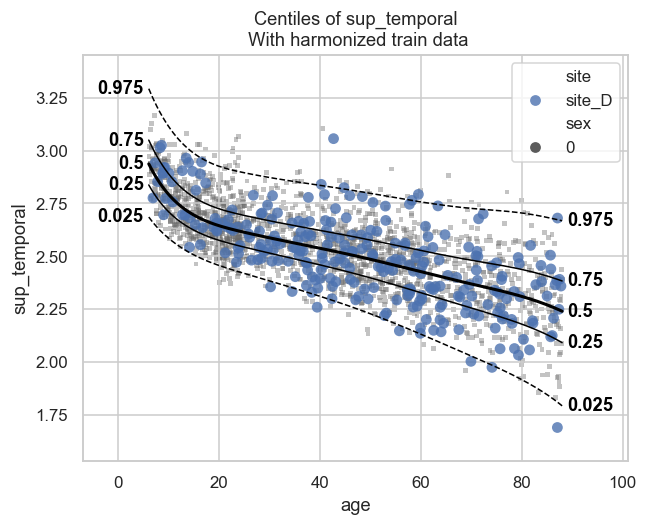

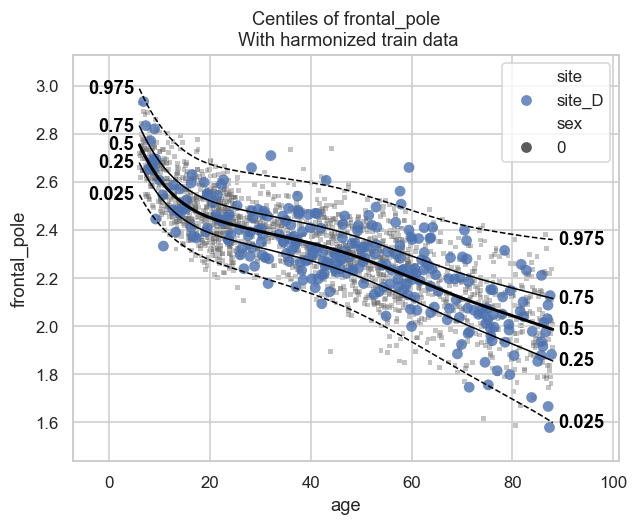

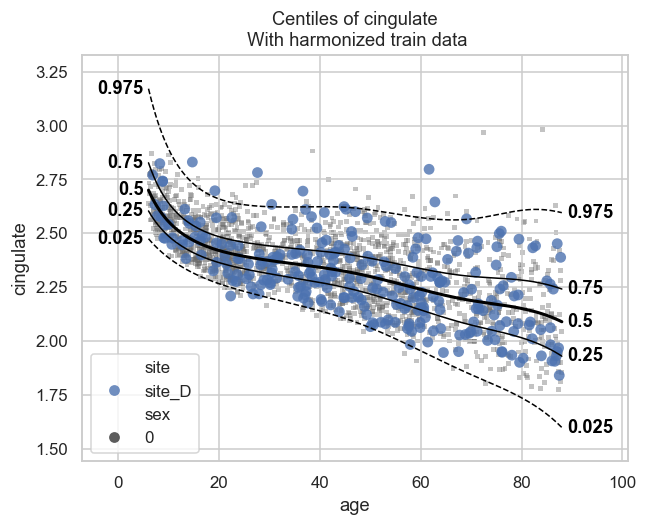

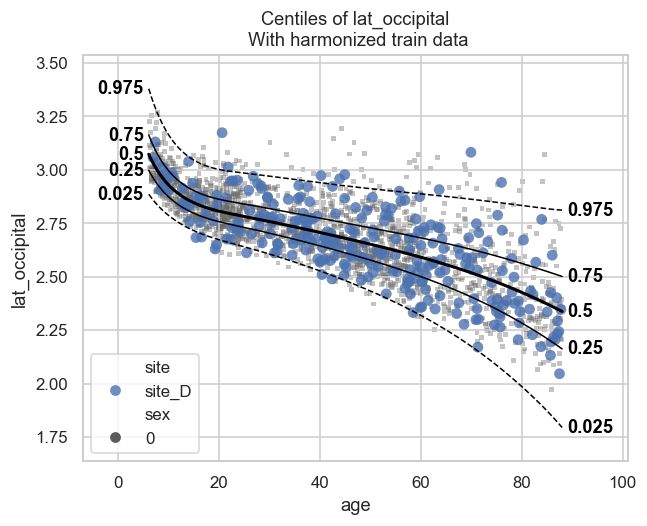

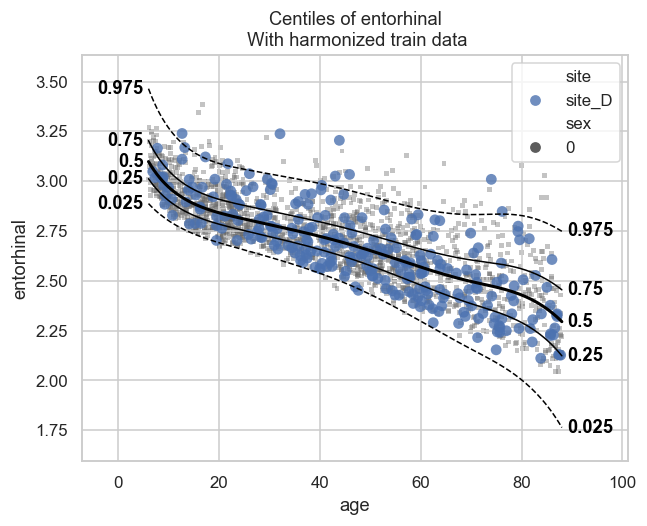

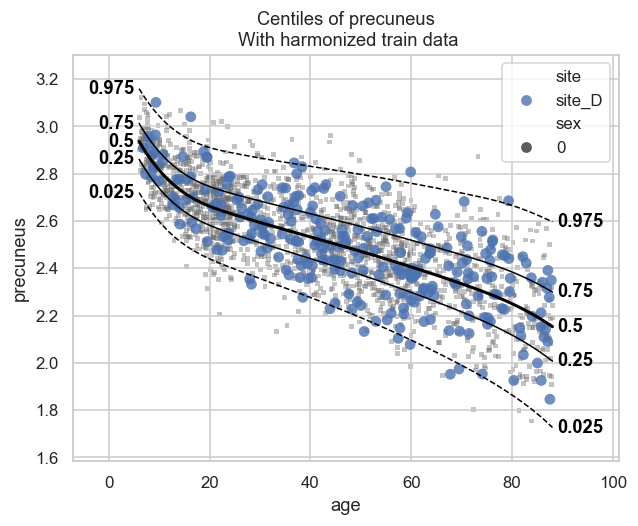

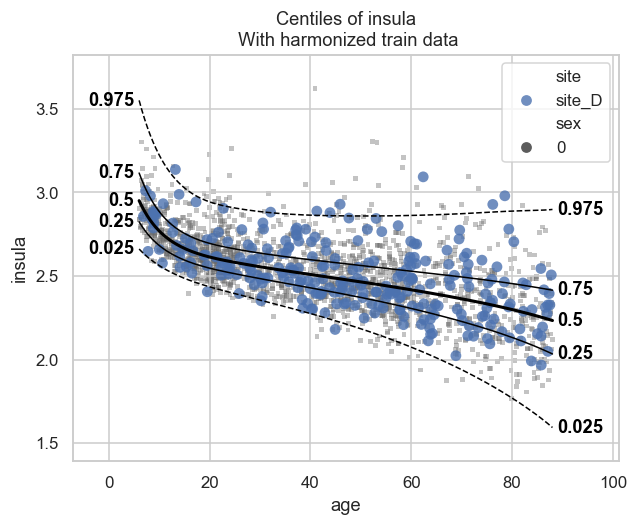

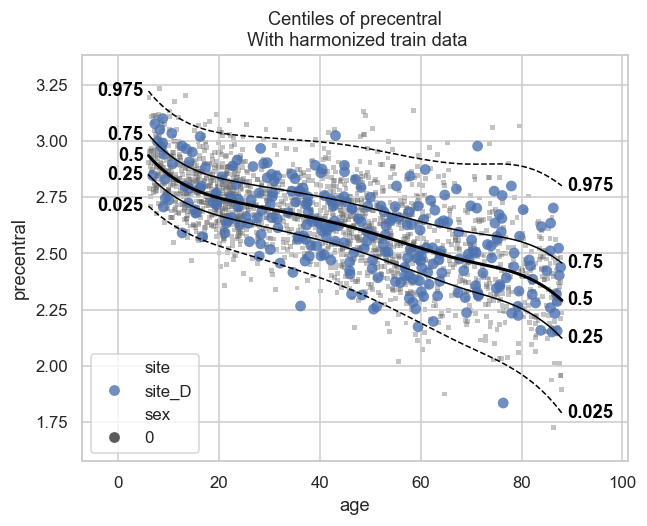

In [ ]:
if HAVE_PCN:
    plot_centiles_advanced(
        wblr,                                              # the fitted model to draw centiles from
        scatter_data=nd_train_w,                           # which subjects to show as dots
        centiles=[0.025, 0.25, 0.5, 0.75, 0.975],          # same centiles as our own plot in 3.5
        batch_effects={"site": ["site_D"], "sex": ["0"]},  # draw curves for this batch (values are strings)
        show_other_data=True,                              # also show subjects from other batches...
        harmonize_data=True,                               # ...mapped to site_D / sex 0 so they're comparable
    );

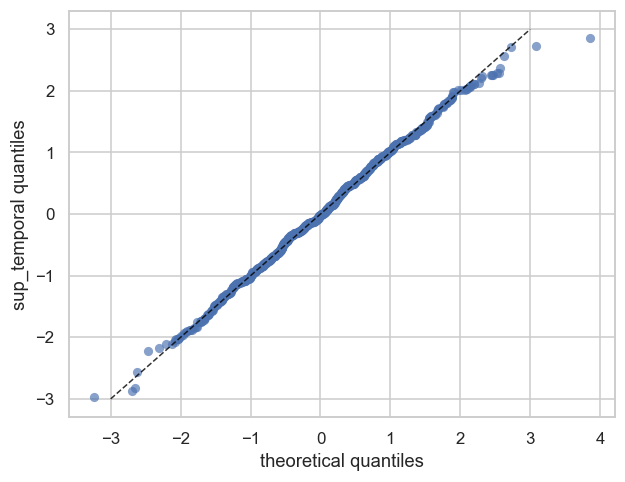

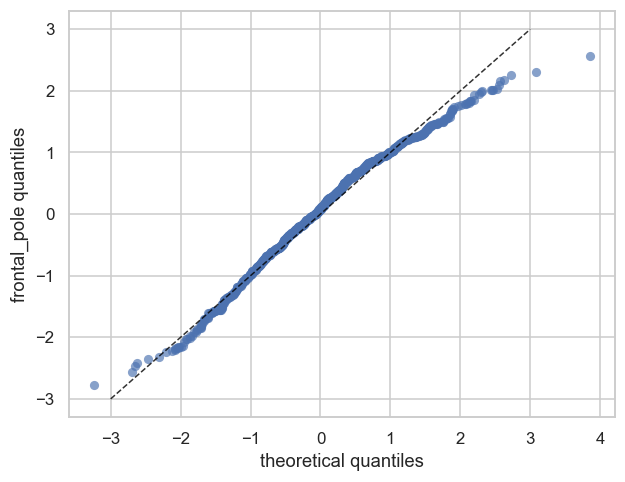

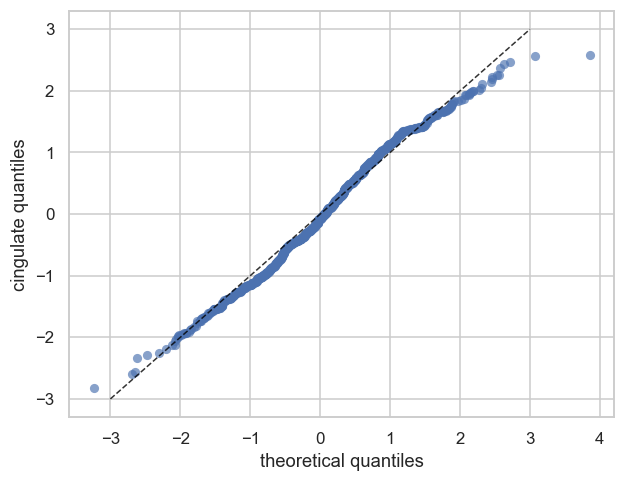

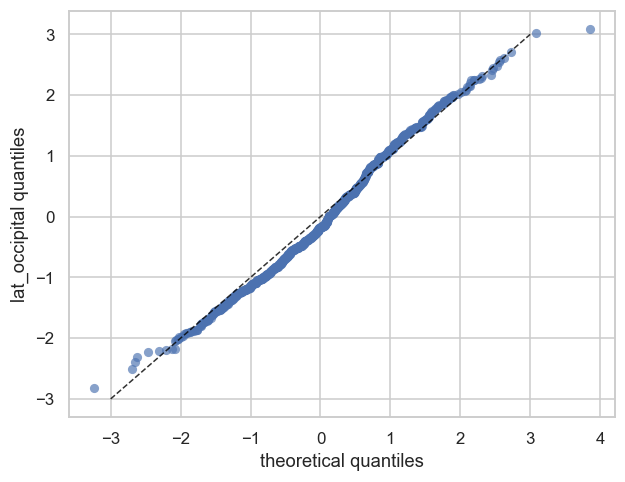

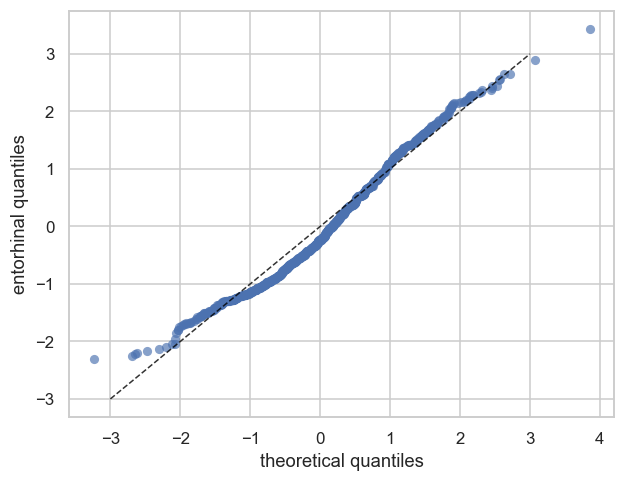

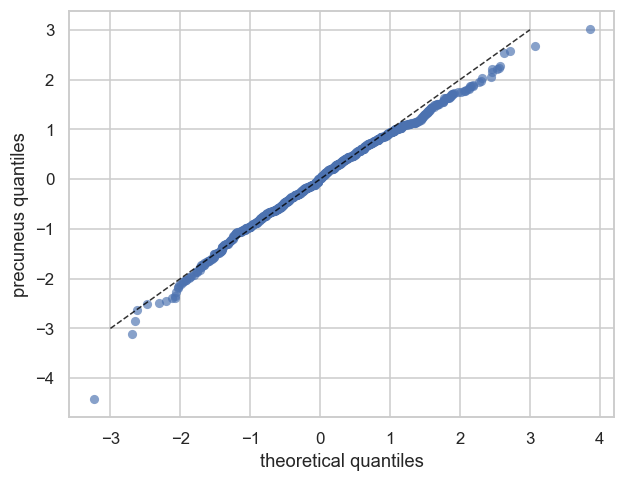

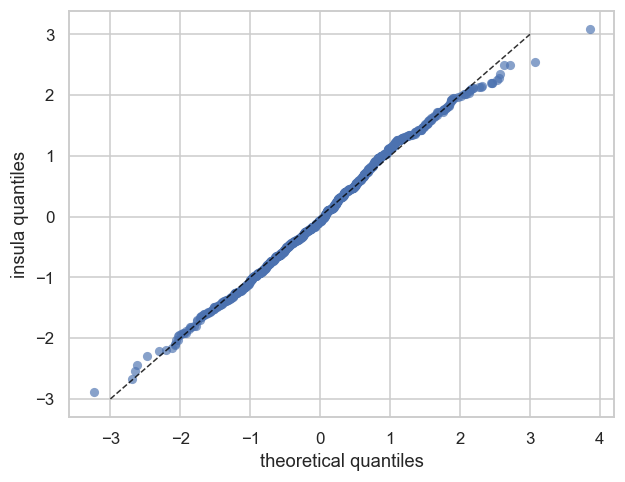

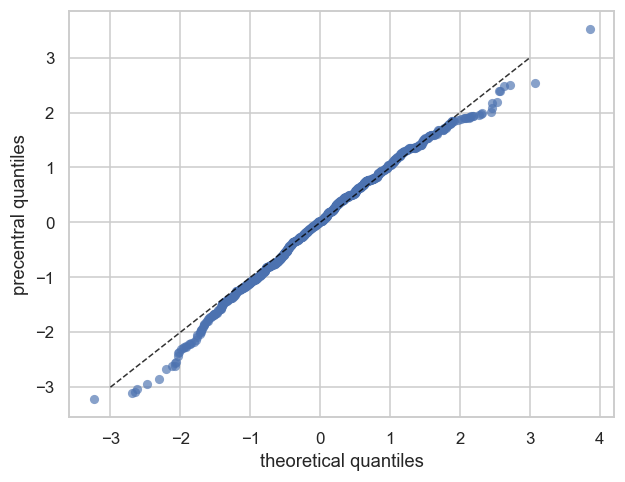

In [ ]:
if HAVE_PCN:
    # Q-Q plot per region of the held-out controls' z-scores under the warped model.
    plot_qq(nd_test_w, plot_id_line=True);

### Beyond this session
The same `NormativeModel` object supports:
- `harmonize(data, reference_batch_effect={...})`: remove site effects from the raw data;
- `synthesize(...)`: sample synthetic subjects from the fitted model;
- `transfer(...)` / `extend(...)`: adapt a model to a **new site** using a small sample of its controls (see the *Transfer and extend* tutorial; `HBR` supports transfer);
- `merge(...)` and federated fitting across institutions without sharing raw data;
- `Runner(...)`: fit thousands of models (vertices/voxels) in parallel on SLURM/Torque clusters.

### ✏️ Exercise 4a (5 min)
Refit the warped model with `fixed_effect_var=False`. Compare `% |z|>1.96` **per site** with the full model (hint: `pd.Series(np.abs(Z[:, j]) > 1.96).groupby(test.site).mean()`). Why does site-specific variance matter for clinical use?

In [ ]:
# Exercise 4a — your code here
# Tip: copy make_model() and change fixed_effect_var; use z_frame() to get the z-scores.

## 5. Clinical application: mapping individual deviations (≈ 17 min)

Now the payoff. We use the z-scores from the best available model (warped BLR if PCNtoolkit ran; otherwise our from-scratch model). A common convention flags **|z| > 2.6** (≈ p < .01, two-sided) as an *extreme deviation*. Here we focus on negative deviations (thinning).

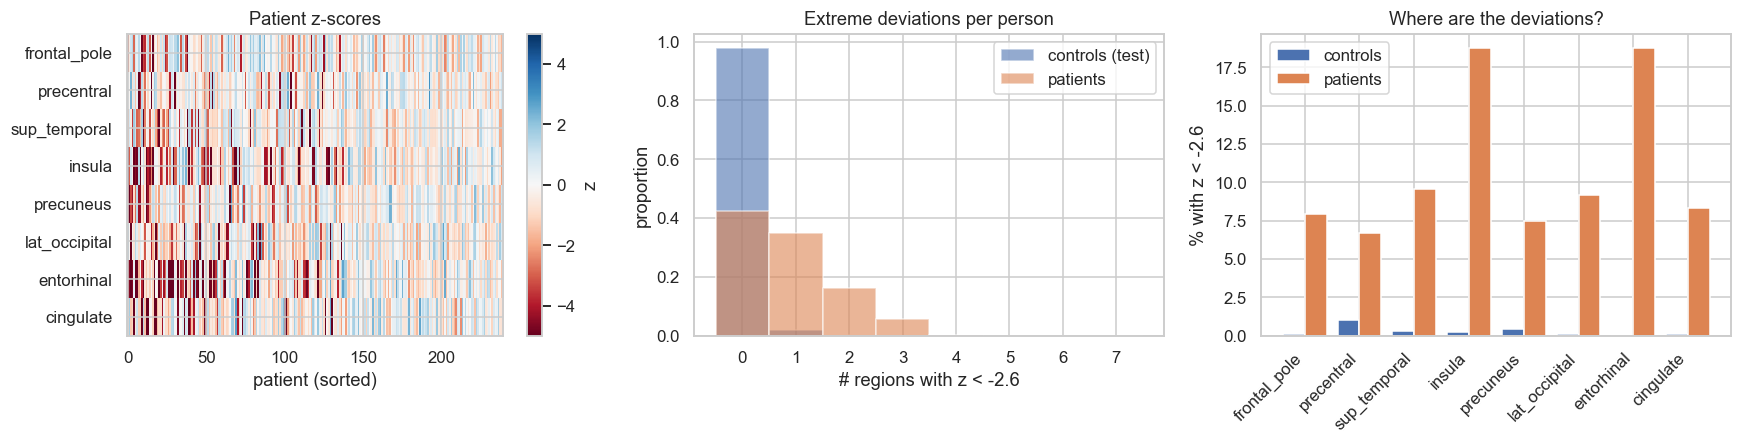

In [ ]:
# Use the best available z-scores: warped BLR if PCNtoolkit ran, otherwise our own model.
Zc, Zp = (Z_wblr_test, Z_wblr_pat) if HAVE_PCN else (Z_test, Z_pat)   # controls, patients

# "Extreme deviation" = z below -2.6 (one-sided p ≈ 0.005). We look at thinning only.
THR = -2.6
ext_ctrl, ext_pat = Zc < THR, Zp < THR     # boolean (subjects x regions) matrices

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (a) Heatmap: rows = regions, columns = patients, sorted so patients with the
#     most extreme deviations come first. Red = thinner than expected.
order = np.argsort(-ext_pat.sum(1))
im = axes[0].imshow(Zp[order].T, aspect="auto", cmap="RdBu", vmin=-5, vmax=5, interpolation="nearest")
axes[0].set(yticks=range(N_ROI), yticklabels=ROIS, xlabel="patient (sorted)", title="Patient z-scores")
plt.colorbar(im, ax=axes[0], label="z")

# (b) How many regions is each person extreme in? (a simple individual-level summary)
bins = np.arange(-0.5, N_ROI + 0.5)        # integer-centred bins: 0, 1, 2, ...
axes[1].hist(ext_ctrl.sum(1), bins=bins, density=True, alpha=0.6, label="controls (test)")
axes[1].hist(ext_pat.sum(1), bins=bins, density=True, alpha=0.6, label="patients")
axes[1].set(xlabel="# regions with z < -2.6", ylabel="proportion", title="Extreme deviations per person")
axes[1].legend()

# (c) "Overlap map": in each region, what % of each group is extreme?
x = np.arange(N_ROI)
axes[2].bar(x - 0.2, 100 * ext_ctrl.mean(0), 0.4, label="controls")
axes[2].bar(x + 0.2, 100 * ext_pat.mean(0), 0.4, label="patients")
axes[2].set(xticks=x, ylabel="% with z < -2.6", title="Where are the deviations?")
axes[2].set_xticklabels(ROIS, rotation=45, ha="right"); axes[2].legend()
plt.tight_layout(); plt.show()

**Reading the figure:**
- **(a)** Almost no two patients share the same pattern — the "average patient" doesn't exist.
- **(b)** Many patients have one or more extreme deviations; almost no controls do. This per-person *count* is itself a useful summary measure.
- **(c)** No single region is abnormal in more than a minority of patients, which is why the group-level t-tests in Section 2 looked unimpressive.

Because the data are simulated, we can also check how accurately deviations recover the ground truth.

In [ ]:
# Compare flagged deviations with the ground-truth abnormality mask (patient x region cells).
tp = (ext_pat & truth).sum()     # true positives : flagged AND truly abnormal
fn = (~ext_pat & truth).sum()    # false negatives: missed abnormalities
fp = (ext_pat & ~truth).sum()    # false positives: flagged but actually normal
tn = (~ext_pat & ~truth).sum()   # true negatives
print(f"Sensitivity: {tp / (tp + fn):.2f}   Specificity: {tn / (tn + fp):.3f}")

# In healthy held-out controls every flag is a false positive. For a calibrated
# model, P(z < -2.6) = 0.47%, so that's the rate we expect.
print(f"False-positive rate in held-out controls: {100 * ext_ctrl.mean():.2f}%  (nominal ≈ 0.47%)")

# Group-level statistics are still available, now on covariate-adjusted z-scores.
print("\nGroup-level test on z-scores (patients vs. controls):")
pd.DataFrame({"mean z (patients)": Zp.mean(0).round(2),
              "t-test p": [stats.ttest_ind(Zp[:, j], Zc[:, j]).pvalue for j in range(N_ROI)],
              "% patients extreme": (100 * ext_pat.mean(0)).round(1),
              "% patients truly abnormal": (100 * truth.mean(0)).round(1)}, index=ROIS)

Sensitivity: 0.85   Specificity: 0.996
False-positive rate in held-out controls: 0.29%  (nominal ≈ 0.47%)

Group-level test on z-scores (patients vs. controls):


,mean z (patients),t-test p,% patients extreme,% patients truly abnormal
frontal_pole,-0.25,1.091419e-04,7.9,8.3
precentral,-0.33,7.288569e-05,6.7,7.9
sup_temporal,-0.45,2.502248e-09,9.6,11.2
insula,-0.87,3.493297e-21,18.8,20.8
precuneus,-0.37,2.115701e-06,7.5,8.8
lat_occipital,-0.52,2.149495e-07,9.2,10.8
entorhinal,-0.95,1.927179e-18,18.8,21.2
cingulate,-0.42,9.343554e-06,8.3,9.2


Normative modelling does **not** replace group statistics — you can still test mean z-scores between groups, with the bonus that age, sex and site are already accounted for. It *adds* the individual level.

### ✏️ Exercise 5a (5 min)
If PCNtoolkit ran, repeat the false-positive analysis using the **non-warped** z-scores (`Z_test` from Section 3). Which regions produce excess false positives, and in which direction? What would this mean for a clinical study of the entorhinal cortex?

### ✏️ Exercise 5b (open)
Use the patient × region matrix of z-scores as features: cluster patients (e.g. `sklearn.cluster.KMeans`) or predict a clinical variable. What are the risks of interpreting clusters found this way as "subtypes"?

In [ ]:
# Exercise 5a / 5b — your code here
# Tip for 5b: from sklearn.cluster import KMeans; KMeans(n_clusters=3, n_init=10).fit_predict(Zp)

## 6. Pitfalls, discussion & wrap-up (≈ 8 min)

**Common pitfalls**
1. **The reference cohort defines "normal".** A model trained on healthy, highly educated, mostly white volunteers encodes that population. Deviations are always relative to *who was in the reference sample*.
2. **Unseen sites.** Z-scores from a site not in training can be biased. Include some controls from each new site, and use a model that supports site adaptation or transfer (e.g. HBR).
3. **Extrapolation.** Centiles outside the training age range are guesses; check age coverage per site.
4. **Checking only overall calibration.** Check calibration by age, sex and site — and look at the tails.
5. **Deviation ≠ disease.** An extreme deviation is statistically unusual, not necessarily pathological. Multiple comparisons across thousands of vertices also produce many chance "extremes".
6. **Covariate choice.** Don't include covariates that are *consequences* of the condition (e.g. total brain volume for an atrophy disorder) unless you mean to.

**Discussion questions**
- For your own data, what would the reference cohort be, and what could bias it?
- When would you prefer z-scores over raw values as input to downstream machine learning?
- How would you communicate an individual's deviation map to a clinician?

**Key references**
- Marquand et al. (2016). Understanding heterogeneity in clinical cohorts using normative models. *Biological Psychiatry*.
- Marquand et al. (2019). Conceptualizing mental disorders as deviations from normative functioning. *Molecular Psychiatry*.
- Fraza et al. (2021). Warped Bayesian linear regression for normative modelling of big data. *NeuroImage*.
- Rutherford et al. (2022). The normative modeling framework for computational psychiatry. *Nature Protocols*.
- Rutherford et al. (2022). Charting brain growth and aging at high spatial precision. *eLife*.
- Bethlehem et al. (2022). Brain charts for the human lifespan. *Nature*.
- de Boer et al. (2024). Non-Gaussian normative modelling with hierarchical Bayesian regression. *Imaging Neuroscience*.
- PCNtoolkit documentation and tutorials: https://pcntoolkit.readthedocs.io

---
## Solutions

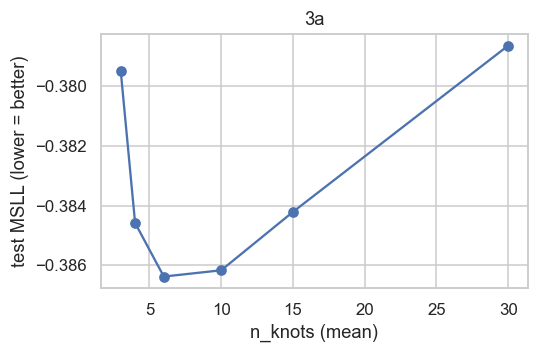

In [ ]:
# Solution 3a — flexibility vs. overfitting
# Refit the model with more and more knots for the mean and track test-set MSLL.
roi = "precuneus"
knots = [3, 4, 6, 10, 15, 30]
msll = [evaluate(test[roi].values,
                 *GaussianNormativeModel(n_knots_mean=k).fit(train, train[roi].values).predict(test),
                 train[roi].values)["MSLL"] for k in knots]
plt.figure(figsize=(5, 3)); plt.plot(knots, msll, "o-")
plt.xlabel("n_knots (mean)"); plt.ylabel("test MSLL (lower = better)"); plt.title("3a"); plt.show()
# MSLL improves quickly up to a handful of knots and then plateaus: extra flexibility
# buys nothing on held-out data (and with smaller samples it would start to hurt).

In [ ]:
# Solution 3b — ignoring site
# A Design subclass that always drops the site columns...
class NoSiteDesign(Design):
    def __call__(self, df, sex=True, site=True):
        return super().__call__(df, sex=sex, site=False)

# ...and a model that uses it for both the mean and the variance.
class NoSiteModel(GaussianNormativeModel):
    def __init__(self):
        super().__init__(var_site=False)
        self.dm, self.dv = NoSiteDesign(6), NoSiteDesign(4)

roi = "precuneus"
z_site = GaussianNormativeModel().fit(train, train[roi].values).zscore(test, test[roi].values)
z_nosite = NoSiteModel().fit(train, train[roi].values).zscore(test, test[roi].values)

# % of |z| > 1.96 per site: should be ~5 everywhere.
# Without site terms, sites with a larger/smaller spread or a shifted mean get too many/too few
# "extreme" z-scores. If patients come mostly from one site, site effects masquerade as disease effects.
pd.DataFrame({"with site": pd.Series(np.abs(z_site) > 1.96).groupby(test.site).mean() * 100,
              "no site": pd.Series(np.abs(z_nosite) > 1.96).groupby(test.site).mean() * 100}).round(1)

,with site,no site
site,,
site_A,5.2,4.3
site_B,4.2,2.5
site_C,3.3,4.8
site_D,4.6,7.5


In [ ]:
# Solution 3c — site effect on the mean only, not on the variance
roi = "precuneus"
m = GaussianNormativeModel(var_site=False).fit(train, train[roi].values)
z = m.zscore(test, test[roi].values)

# SD of the z-scores per site should be ~1. Without a site term in the variance model
# it drifts above 1 at noisy sites and below 1 at quiet sites.
pd.Series(z).groupby(test.site).std().round(2)

site
site_A    0.99
site_B    0.89
site_C    1.01
site_D    1.01
dtype: float64

In [ ]:
# Solution 4a — warped BLR without a batch effect on the variance (requires PCNtoolkit)
if HAVE_PCN:
    reg = BLR(name="template", basis_function_mean=BsplineBasisFunction(degree=3, nknots=5),
              heteroskedastic=True, fixed_effect=True,
              fixed_effect_var=False,                  # <- the only change from make_model()
              warp_name="WarpSinhArcsinh", warp_reparam=True)
    m = NormativeModel(template_regression_model=reg, savemodel=False, saveresults=False, saveplots=False,
                       evaluate_model=True, save_dir="pcn_work", inscaler="standardize", outscaler="standardize")
    tr, te = to_normdata("train", train), to_normdata("test", test)
    m.fit_predict(tr, te)
    Z_novar = z_frame(te, test.index)

    # % |z| > 1.96 per site for one region, with vs. without site-specific variance
    j = ROIS.index("precuneus")
    display(pd.DataFrame({
        "site var (full model)": pd.Series(np.abs(Z_wblr_test[:, j]) > 1.96).groupby(test.site).mean() * 100,
        "no site var": pd.Series(np.abs(Z_novar[:, j]) > 1.96).groupby(test.site).mean() * 100}).round(1))
    # Sites with noisier scanners get too many "extreme" deviations, quieter sites too few.

# Solution 5a — tail-specific false-positive rates in healthy controls
# For a calibrated model each tail should contain ~0.47% of controls (z < -2.6 or z > +2.6).
fp_tab = {"Gaussian: % z<-2.6": (100 * (Z_test < -2.6).mean(0)).round(2),
          "Gaussian: % z>+2.6": (100 * (Z_test > 2.6).mean(0)).round(2)}
if HAVE_PCN:
    fp_tab["warped BLR: % z<-2.6"] = (100 * (Z_wblr_test < -2.6).mean(0)).round(2)
    fp_tab["warped BLR: % z>+2.6"] = (100 * (Z_wblr_test > 2.6).mean(0)).round(2)
# With positive skew, the Gaussian model over-flags the upper tail and under-flags the lower tail,
# so it would miss genuine thinning in skewed regions.
pd.DataFrame(fp_tab, index=ROIS)

,site var (full model),no site var
site,,
site_A,4.8,5.2
site_B,3.3,2.9
site_C,2.9,2.9
site_D,3.8,3.8


,Gaussian: % z<-2.6,Gaussian: % z>+2.6,warped BLR: % z<-2.6,warped BLR: % z>+2.6
frontal_pole,0.00,0.33,0.11,0.00
precentral,0.67,0.78,1.00,0.11
sup_temporal,0.00,1.44,0.33,0.33
insula,0.00,1.78,0.22,0.11
precuneus,0.33,0.67,0.44,0.22
lat_occipital,0.00,1.44,0.11,0.44
entorhinal,0.00,2.00,0.00,0.44
cingulate,0.00,1.56,0.11,0.00
